<a href="https://colab.research.google.com/github/roghayefazli/Lung-Cancer-prediction-resnet-base/blob/main/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50 as pretrainedModel , preprocess_input

In [ ]:
from tensorflow.keras.layers import Flatten, Dense

In [ ]:
from keras import models
from tensorflow.keras.models import Model

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
train_path = '/content/data/train'

In [ ]:
valid_path = '/content/data/test'

In [ ]:
image_size= [50,50]

In [ ]:
from glob import glob

In [ ]:
imageFiles = glob( train_path + '/*/*.jpeg')

In [ ]:
imageFiles

['/content/data/train/ill/5.jpeg',
 '/content/data/train/ill/2.jpeg',
 '/content/data/train/ill/3.jpeg',
 '/content/data/train/ill/4.jpeg',
 '/content/data/train/ill/1.jpeg',
 '/content/data/train/ill/6.jpeg',
 '/content/data/train/normal/5.jpeg',
 '/content/data/train/normal/2.jpeg',
 '/content/data/train/normal/3.jpeg',
 '/content/data/train/normal/4.jpeg',
 '/content/data/train/normal/1.jpeg',
 '/content/data/train/normal/6.jpeg']

In [ ]:
validFiles = glob( valid_path + '/*/*.jpeg')

In [ ]:
validFiles

['/content/data/test/ill/5.jpeg',
 '/content/data/test/ill/2.jpeg',
 '/content/data/test/ill/3.jpeg',
 '/content/data/test/ill/4.jpeg',
 '/content/data/test/ill/1.jpeg',
 '/content/data/test/ill/6.jpeg',
 '/content/data/test/normal/5.jpeg',
 '/content/data/test/normal/2.jpeg',
 '/content/data/test/normal/3.jpeg',
 '/content/data/test/normal/4.jpeg',
 '/content/data/test/normal/1.jpeg',
 '/content/data/test/normal/6.jpeg']

In [ ]:
folders = glob(train_path + '/*')

In [ ]:
folders

['/content/data/train/ill', '/content/data/train/normal']

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

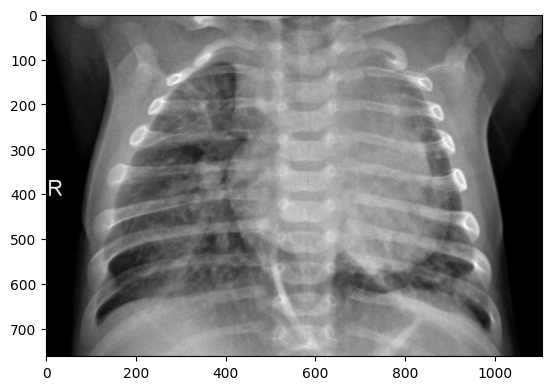

In [ ]:
plt.imshow(image.load_img(np.random.choice(imageFiles)))

In [ ]:
ptm = pretrainedModel(

input_shape = image_size + [3],
weights= 'imagenet',
include_top = False



)

94765736/94765736 [==============================] - 1s 0us/step


In [ ]:
ptm.trainable = False

In [ ]:
k = len(folders)

In [ ]:
x = Flatten()(ptm.output)
x = Dense(k, activation = 'softmax')(x)
model = Model (inputs = ptm.input, outputs = x)

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
gen = ImageDataGenerator(

  rotation_range=20,
  width_shift_range=0.1,
  height_shift_range=0.1,
  preprocessing_function= preprocess_input


)

In [ ]:
batchsize = 128

In [ ]:
train_generator = gen.flow_from_directory(
    train_path,
    shuffle=True,
    target_size= image_size,
    batch_size= batchsize




)

Found 12 images belonging to 2 classes.


In [ ]:
valid_generator = gen.flow_from_directory(
    valid_path,
    shuffle=True,
    target_size= image_size,
    batch_size= batchsize



)

Found 12 images belonging to 2 classes.


In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [ ]:
r = model.fit_generator(train_generator, validation_data= valid_generator, epochs =5)

<ipython-input-34-6d96cb70fab0>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  r = model.fit_generator(train_generator, validation_data= valid_generator, epochs =5)


Epoch 1/5
1/1 [==============================] - 7s 7s/step - loss: 2.6006 - accuracy: 0.5000 - val_loss: 3.4016 - val_accuracy: 0.5000
Epoch 2/5
1/1 [==============================] - 1s 681ms/step - loss: 2.6230 - accuracy: 0.5000 - val_loss: 2.1194 - val_accuracy: 0.4167
Epoch 3/5
1/1 [==============================] - 1s 693ms/step - loss: 0.7303 - accuracy: 0.7500 - val_loss: 2.4533 - val_accuracy: 0.3333
Epoch 4/5
1/1 [==============================] - 1s 693ms/step - loss: 0.5803 - accuracy: 0.8333 - val_loss: 1.6346 - val_accuracy: 0.2500
Epoch 5/5
1/1 [==============================] - 1s 677ms/step - loss: 0.6389 - accuracy: 0.8333 - val_loss: 2.5951 - val_accuracy: 0.5833


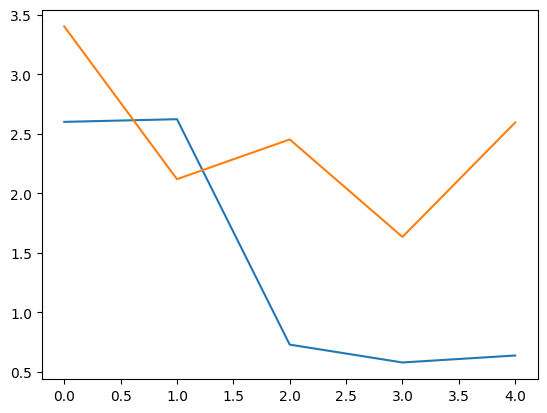

In [ ]:
plt.plot(r.history['loss'], label = 'loss')
plt.plot(r.history['val_loss'], label = 'val_loss')

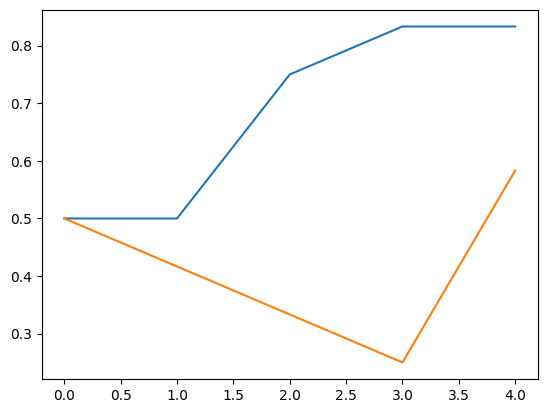

In [ ]:
plt.plot(r.history['accuracy'], label = 'accuracy')
plt.plot(r.history['val_accuracy'], label = 'val_accuracy')